####======================================================
### **Homework Assignment 7**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing seed data from *seeds_dataset.txt* to try different dimensionality reduction and classification techniques. The dataset contains 210 data points (rows) and has 7 features (columns), plus the label (1, 2, or 3).

1. The data was loaded and put into a feature matrix, X, and a target vector, y.
2. T-SNE was used to plot the data with respect to its first 2 principal components. The data points were also plotted against features 2 and 5.
3. A logistic regression classifier with all 7 features was built
4. A logistic regression classifier with 2 principal components as features was built
5. A logistic regression classifier with features 2 and 5 was built

    

#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [85]:
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from distutils.version import LooseVersion

from matplotlib.colors import ListedColormap
import matplotlib.patheffects as PathEffects
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, adjusted_rand_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

#### ====================================================
#### LOAD + PREPARE DATA
#### ======================================================

In [86]:
# create dataframe (df) from the input file
df = pd.read_csv('seeds_dataset.txt', sep = '\s+', header = None)

# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6,7
0,0,0,0,0,0,0,0,0


In [87]:
# make X matrix and rename columns
X = df.iloc[:, :7].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5', 6: 'f6'})
X

,f0,f1,f2,f3,f4,f5,f6
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175
...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044


In [88]:
# make y vector (labels 1,2,3)
y = df.iloc[:, 7:].rename(columns={7: 'label'})
y

,label
0,1
1,1
2,1
3,1
4,1
...,...
205,3
206,3
207,3
208,3


In [89]:
# get count of labels in y
y.value_counts()

,count
label,
1,70
2,70
3,70


In [90]:
y

,label
0,1
1,1
2,1
3,1
4,1
...,...
205,3
206,3
207,3
208,3


#### ====================================================
#### T-SNE
#### ======================================================



In [91]:
tsne = TSNE(n_components=2, init='pca', random_state=305)

X_tsne = tsne.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


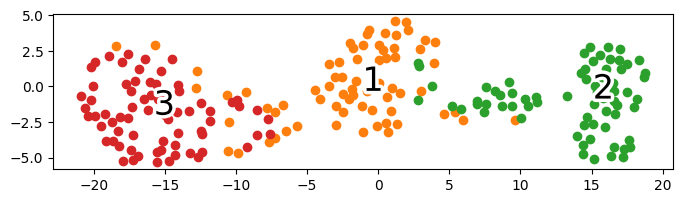

In [92]:
# code sourced from chp5tsne.ipynb
def plot_projection(x, colors):

    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect='equal')
    for i in range(10):
        plt.scatter(x[colors == i, 0],
                    x[colors == i, 1])

    for i in range(10):

        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()])

plot_projection(X_tsne, y['label'])
plt.show()

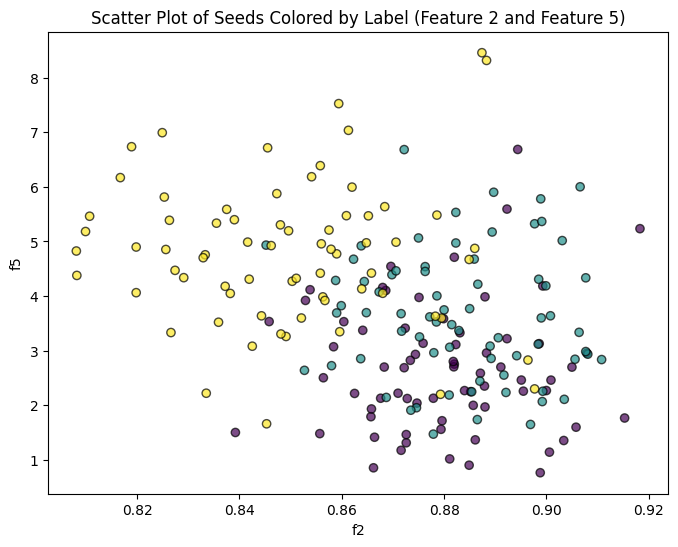

In [93]:
# randomly select 2 features
feature_1, feature_2 = "f2", "f5"

plt.figure(figsize=(8, 6))

plt.scatter(X[feature_1], X[feature_2], c=y['label'], cmap='viridis', alpha=0.7, edgecolors='k')

# Labels and title
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.title("Scatter Plot of Seeds Colored by Label (Feature 2 and Feature 5)")

plt.show()


#### ====================================================
#### K-Means + Hierarchical Clustering + DBSCAN
#### ======================================================




Adjusted Rand Index Scores:

K-Means: 0.7166
Hierarchical Clustering: 0.7132
DBSCAN: 0.0557



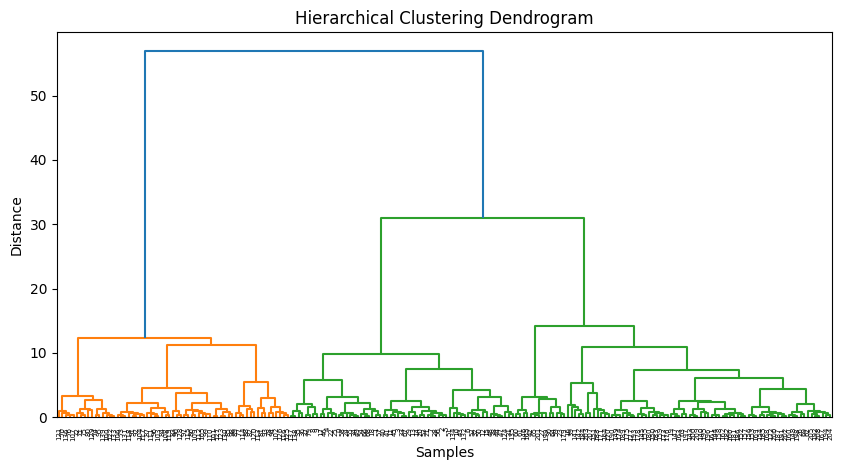

In [94]:
n_clusters = len(np.unique(y))

# K-Means Clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=305, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Hierarchical Clustering (Agglomerative)
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
hierarchical_labels = hierarchical.fit_predict(X)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Adjusted Rand Index (ARI) Scores
ari_kmeans = adjusted_rand_score(y['label'], kmeans_labels)
ari_hierarchical = adjusted_rand_score(y['label'], hierarchical_labels)
ari_dbscan = adjusted_rand_score(y['label'], dbscan_labels)

print(f"\nAdjusted Rand Index Scores:\n")
print(f"K-Means: {ari_kmeans:.4f}")
print(f"Hierarchical Clustering: {ari_hierarchical:.4f}")
print(f"DBSCAN: {ari_dbscan:.4f}\n")

# Plot Hierarchical Clustering Dendrogram
plt.figure(figsize=(10, 5))
linkage_matrix = linkage(X, method='ward')
dendrogram(linkage_matrix)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


#### ====================================================
#### Logistic Regression (All Features)
#### ======================================================


In [95]:
# split data into a training set (70%) and a testing set (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 305, stratify = y)

In [96]:
# get counts of labels in y_train and y_test
print(y_train.value_counts())
print(y_test.value_counts())

label
1        49
2        49
3        49
Name: count, dtype: int64
label
1        21
2        21
3        21
Name: count, dtype: int64


In [97]:
# standardize features in X
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [98]:
# create a logistic regression classifier for all features in matrix X
logreg1 = LogisticRegression(random_state=305, max_iter=1000)  # You can adjust parameters as needed

# Train the classifier on the training data
logreg1.fit(X_train, y_train.values.ravel())  # ravel() to convert y_train to a 1D array

# Make predictions on the test data
y_pred = logreg1.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9048

              precision    recall  f1-score   support

           1       0.83      0.90      0.86        21
           2       0.95      0.86      0.90        21
           3       0.95      0.95      0.95        21

    accuracy                           0.90        63
   macro avg       0.91      0.90      0.91        63
weighted avg       0.91      0.90      0.91        63



#### ====================================================
#### Logistic Regression (2 Principal Components)
#### ======================================================


In [99]:
# Split the data into training and testing sets (using X_tsne)
X_train_tsne, X_test_tsne, y_train, y_test = train_test_split(X_tsne, y, test_size=0.3, random_state=305, stratify=y)

# Create a logistic regression classifier
logreg2 = LogisticRegression(random_state=305, max_iter=1000)

# Train the classifier on the training data (using X_tsne)
logreg2.fit(X_train_tsne, y_train.values.ravel())

# Make predictions on the test data (using X_tsne)
y_pred_tsne = logreg2.predict(X_test_tsne)

# Evaluate the classifier
accuracy_tsne = accuracy_score(y_test, y_pred_tsne)
print(f"Accuracy with 2 Principal Components (T-SNE): {accuracy_tsne:.4f}\n")
print(classification_report(y_test, y_pred_tsne))

Accuracy with 2 Principal Components (T-SNE): 0.8730

              precision    recall  f1-score   support

           1       0.81      0.81      0.81        21
           2       0.95      0.86      0.90        21
           3       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.88      0.87      0.87        63
weighted avg       0.88      0.87      0.87        63



#### ====================================================
#### Logistic Regression (2 Random Features)
#### ======================================================


In [100]:
# Select features 2 and 5
X_selected = X[['f2', 'f5']]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=305, stratify=y
)

# Create a logistic regression classifier
logreg = LogisticRegression(random_state=305, max_iter=1000)

# Train the classifier on the training data
logreg.fit(X_train, y_train.values.ravel())

# Make predictions on the test data
y_pred = logreg.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with features f2 and f5: {accuracy:.4f}\n")
print(classification_report(y_test, y_pred))

Accuracy with features f2 and f5: 0.6667

              precision    recall  f1-score   support

           1       0.61      0.95      0.74        21
           2       0.54      0.33      0.41        21
           3       0.88      0.71      0.79        21

    accuracy                           0.67        63
   macro avg       0.68      0.67      0.65        63
weighted avg       0.68      0.67      0.65        63



Logistic Regression Classifier Accuracies:

 - All 7 Features = 0.9048

 - 2 Principal Components = 0.8730

 - 2 Arbitrary Features f2 and f5 = 0.6667

From this we can see that the highest prediction accuracy is acheived by the LR model with all 7 features, which makes sense since maintaining the highest dimensionality would have the most information retained, making it 'easier' to predict labels. It allows the most degrees of freedom by which to seperate clusters of data points. By reducing the feature space to 2 dimensions (principal components) we do lose some prediction accuracy however it does a really good job of maintaining high prediction accuracy, since the principal components capture the maximum variance in the data points, while at the same time reducing the dimensionality significantly from 7 to 2. I personally think that this model is the best in terms of accuracy-complexity tradeoff. Lastly, for comparison, the logistic regression classifier with 2 arbitrary features, f2 and f5, does the worst, since it doesn't do a great job capturing much differentiation between labels. This is evident from the scatter plot generated above.